In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

# Partie 1

In [105]:
C = 10e-9  # F
R_plot = 218
R = R_plot*1e3
L = 100e-3          #H
file = f'Bode_{R_plot}.csv'

def model(f, f0, A, Q):
    return A / np.sqrt(1 + Q**2 * (f/f0 - f0/f)**2)

def Qint(Q, R, f0, C=C):
    omega0 = 2*np.pi*f0
    Q_ext = R * C * omega0
    return 1/ (1/Q_loaded - 1/Q_ext)

def Rp(Qint, f0, C=C):
    omega0 = 2*np.pi*f0
    return Qint / (C * omega0)

def pertes(Rp, R):
    return Rp/(R+Rp)

df = pd.read_csv(file)
freq = df['Frequency [Hz]'].to_numpy()
gain_db = df[' Amplitude [dB]'].to_numpy() 
phase =  df[' Phase [deg]'].to_numpy() 
amp = 10**(gain_db / 20.0)  

p0 = (np.mean(freq), np.max(amp), 50.0) 
bounds = ([0, 0, 1e-1], [np.max(freq)*2, 10.0, 1e4])  

popt, pcov = curve_fit(model, freq, amp, p0=p0, bounds=bounds, maxfev=20000)
f0_fit, A_fit, Q_fit = popt
perr = np.sqrt(np.diag(pcov))

omega0 = 2*np.pi*f0_fit
Q_loaded = Q_fit
Q_int = Qint(Q_loaded, R, f0=f0_fit) 
Rp_val = Rp(Q_int, f0_fit)
Rp_pertes = A_fit*R/(1-A_fit)

print("Résultats du fit")
print(f"f0 = {f0_fit:.3f} Hz ± {perr[0]:.3f}")
print(f"A  = {A_fit:.5f} ± {perr[1]:.5f}")
print(f"Q_loaded = {Q_loaded:.3f} ± {perr[2]:.3f}")
print(f"omega0 = {omega0:.3f} rad/s")
#print(f"Q_int = {Q_int:.3f}")
#print(f"Rp (from Q_int) = {Rp_val/1e3:.2f} kΩ")
#print(f"pertes {pertes(Rp_val, R)}")
print(f"Rp à partir des pertes {Rp_pertes:.3f}")
print(f"Q à partir des pertes {Rp_pertes*R/(Rp_pertes + R)*C*omega0:.3f}")
print(f"Qint à partir des pertes {Rp_pertes*C*omega0:.3f}")

f_fine = np.linspace(np.min(freq), np.max(freq), 1000)

Résultats du fit
f0 = 5087.477 Hz ± 6.181
A  = 0.46205 ± 0.04174
Q_loaded = 49.738 ± 4.738
omega0 = 31965.562 rad/s
Rp à partir des pertes 187242.132
Q à partir des pertes 32.198
Qint à partir des pertes 59.853


$$pertes = Rp/(R+Rp) $$

$$pertes(R+Rp) = Rp$$

$$pertesR = Rp(pertes -1)$$

<>:20: SyntaxWarning: invalid escape sequence '\O'
<>:20: SyntaxWarning: invalid escape sequence '\O'
C:\Users\jolet\AppData\Local\Temp\ipykernel_12232\3552220663.py:20: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Diagramme de Bode du filtre RCL pour $R = {R/1e3} k\Omega$")


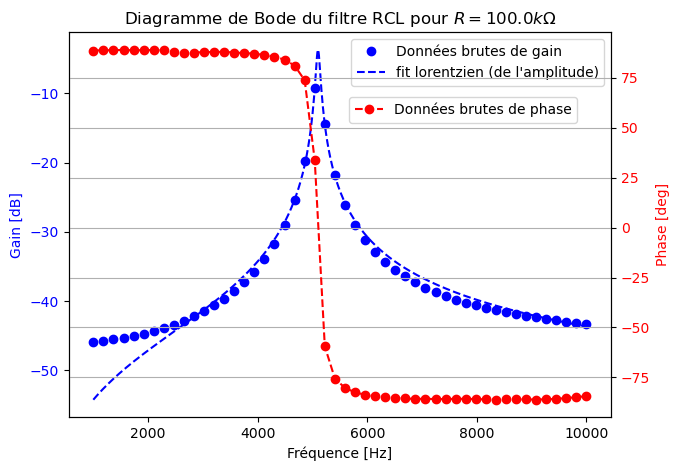

In [100]:
fig, ax1 = plt.subplots(figsize=(7, 5))


plt.plot(freq, gain_db, 'o', color ='b', label ='Données brutes de gain')
plt.plot(f_fine, 20*np.log10(model(f_fine, *popt)), color ='b', linestyle ='--', label="fit lorentzien (de l'amplitude)")
plt.legend()

ax1.set_xlabel('Fréquence [Hz]')
ax1.set_ylabel('Gain [dB]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()
plt.plot(freq, phase, marker ='o', linestyle = '--', color ='r', label ='Données brutes de phase')
ax2.set_ylabel('Phase [deg]', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.legend(loc = 'best', bbox_to_anchor=(0.45, 0., 0.5, 0.85))


plt.title(f"Diagramme de Bode du filtre RCL pour $R = {R/1e3} k\Omega$")
plt.grid(which='both')
plt.show()


# Démarage des oscillations

In [107]:
R2 = 2E3
R1 = 2.2E3
G_dem = 1+R2/R1
Rp = 193e3
R = 218e3
print("Gain au démarrage des oscillations", 1 + R2/R1)

Gain au démarrage des oscillations 1.9090909090909092


In [108]:
1/1.91

0.5235602094240838

In [109]:
(1.91-1)*2

1.8199999999999998

[ 10  30  50  70  90 111 132 152 172 192 213 233 253 273 293 314 334]


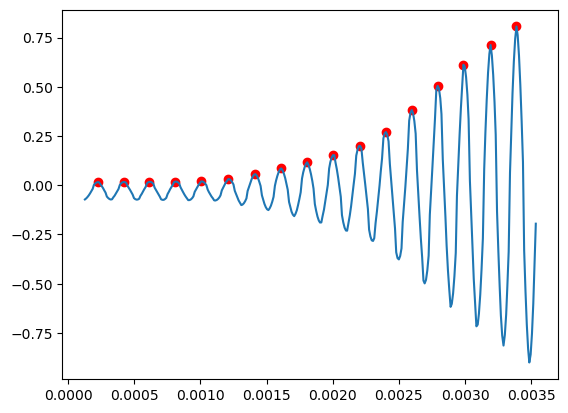

In [110]:
pd.read_csv('scopeData(23).csv')

time = pd.read_csv('scopeData(23).csv')['TIME ms']*1E-3
Vin = pd.read_csv('scopeData(23).csv')[' IN2']
time = time.to_numpy()
Vin = Vin.to_numpy()
time_cropped, Vin_cropped = np.flip(time[150:500]), Vin[150:500]

from scipy.signal import find_peaks

peaks = find_peaks(Vin_cropped, height=None)
plt.plot(time_cropped, Vin_cropped)
print(peaks[0])

x = time_cropped[peaks[0]]
y = Vin_cropped[peaks[0]]
plt.scatter(x, y, color ='r')

1167.9685775092153
13.684255863315405


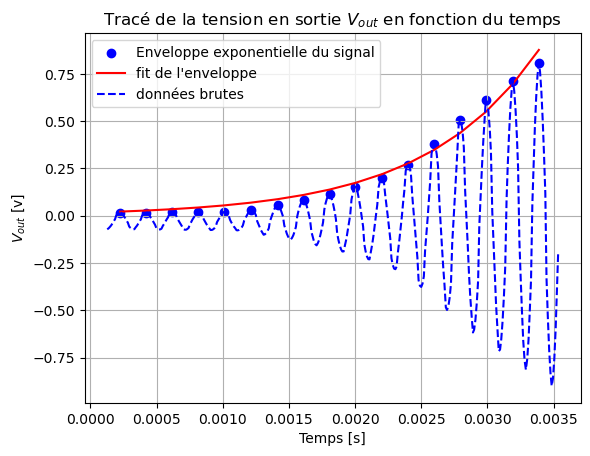

In [111]:
def model_bis(t,alpha,A):
    return A*np.exp(alpha*t)

popt, pcov = curve_fit(model_bis, x,y, p0 = [-800,1])
alpha_bis,A = popt
print(alpha_bis)

Q = 1/(2*alpha_bis)*omega0
print(Q)

#plt.plot(time_cropped, model(time_cropped, *p0))
plt.title('Tracé de la tension en sortie $V_{out}$ en fonction du temps')
plt.scatter(x, y, color ='b', label ='Enveloppe exponentielle du signal')
plt.plot(x,model_bis(x,*popt), color ='r', label ="fit de l'enveloppe")
plt.plot(time_cropped, Vin_cropped, color ='b', linestyle ='--', label ='données brutes')
plt.legend()
plt.xlabel("Temps [s]")
plt.ylabel("$V_{out}$ [v]")
plt.grid()
plt.show()